# Credit Risk Scoring Model

**Author:** Hoshikawa Ran  
**Dataset:** public Kaggle "Credit Risk Dataset" (`credit_risk_dataset.csv`)

This is a cleaned version of the original working notebook: duplicate cells, debug checks, and superseded/broken attempts have been removed. Every remaining cell keeps its **original, real output** exactly as first produced — nothing here was re-run or re-generated, so every chart and number is authentic.

## 1. Load the data and check it

In [24]:
import pandas as pd

df=pd.read_csv(r"C:\Users\nguyen\nguyen\creditriskproject\credit_risk_dataset.csv")
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB


In [26]:
df.describe(include="all")


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,32581,31686.000000,32581,32581,32581.000000,29465.000000,32581.000000,32581.000000,32581,32581.000000
unique,NaN,NaN,4,NaN,6,7,NaN,NaN,NaN,NaN,2,NaN
top,NaN,NaN,RENT,NaN,EDUCATION,A,NaN,NaN,NaN,NaN,N,NaN
freq,NaN,NaN,16446,NaN,6453,10777,NaN,NaN,NaN,NaN,26836,NaN
mean,27.734600,6.607485e+04,NaN,4.789686,NaN,NaN,9589.371106,11.011695,0.218164,0.170203,NaN,5.804211
std,6.348078,6.198312e+04,NaN,4.142630,NaN,NaN,6322.086646,3.240459,0.413006,0.106782,NaN,4.055001
min,20.000000,4.000000e+03,NaN,0.000000,NaN,NaN,500.000000,5.420000,0.000000,0.000000,NaN,2.000000
25%,23.000000,3.850000e+04,NaN,2.000000,NaN,NaN,5000.000000,7.900000,0.000000,0.090000,NaN,3.000000
50%,26.000000,5.500000e+04,NaN,4.000000,NaN,NaN,8000.000000,10.990000,0.000000,0.150000,NaN,4.000000
75%,30.000000,7.920000e+04,NaN,7.000000,NaN,NaN,12200.000000,13.470000,0.000000,0.230000,NaN,8.000000


In [27]:
df["loan_status"].value_counts(normalize=True)


loan_status
0    0.781836
1    0.218164
Name: proportion, dtype: float64

## 2. Data quality checks

In [31]:
pd.options.display.float_format = '{:,.2f}'.format


In [32]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,"32,581.00","32,581.00","31,686.00","32,581.00","29,465.00","32,581.00","32,581.00","32,581.00"
mean,27.73,"66,074.85",4.79,"9,589.37",11.01,0.22,0.17,5.80
std,6.35,"61,983.12",4.14,"6,322.09",3.24,0.41,0.11,4.06
min,20.00,"4,000.00",0.00,500.00,5.42,0.00,0.00,2.00
25%,23.00,"38,500.00",2.00,"5,000.00",7.90,0.00,0.09,3.00
50%,26.00,"55,000.00",4.00,"8,000.00",10.99,0.00,0.15,4.00
75%,30.00,"79,200.00",7.00,"12,200.00",13.47,0.00,0.23,8.00
max,144.00,"6,000,000.00",123.00,"35,000.00",23.22,1.00,0.83,30.00


In [33]:
df["person_income"].quantile([0.95, 0.99, 0.995, 0.999, 1])

0.95     138,000.00
0.99     225,200.00
0.99     300,000.00
1.00     648,000.00
1.00   6,000,000.00
Name: person_income, dtype: float64

## 3. Exploratory analysis — loan purpose and loan grade

In [34]:
df["loan_intent"].value_counts()

loan_intent
EDUCATION            6453
MEDICAL              6071
VENTURE              5719
PERSONAL             5521
DEBTCONSOLIDATION    5212
HOMEIMPROVEMENT      3605
Name: count, dtype: int64

In [35]:
df.groupby("loan_intent")["loan_status"].mean().sort_values(ascending=False)


loan_intent
DEBTCONSOLIDATION   0.29
MEDICAL             0.27
HOMEIMPROVEMENT     0.26
PERSONAL            0.20
EDUCATION           0.17
VENTURE             0.15
Name: loan_status, dtype: float64

In [36]:
df.groupby("person_income")["loan_status"].mean().sort_values(ascending=False)


person_income
604000    1.00
584800    1.00
540600    1.00
499800    1.00
10008     1.00
          ... 
1440000   0.00
1782000   0.00
1900000   0.00
43812     0.00
510000    0.00
Name: loan_status, Length: 4295, dtype: float64

In [38]:
df.groupby("loan_intent").agg(
    default_rate=("loan_status", "mean"),
    borrowers=("loan_status", "count"),
    avg_income=("person_income", "mean"),
    avg_loan=("loan_amnt", "mean"),
    avg_loan_income=("loan_percent_income", "mean")
).sort_values("default_rate")

,default_rate,borrowers,avg_income,avg_loan,avg_loan_income
loan_intent,,,,,
VENTURE,0.15,5719,"66,386.57","9,583.78",0.17
EDUCATION,0.17,6453,"64,135.20","9,482.68",0.17
PERSONAL,0.20,5521,"67,864.14","9,573.77",0.17
HOMEIMPROVEMENT,0.26,3605,"73,549.47","10,360.52",0.17
MEDICAL,0.27,6071,"61,437.23","9,259.58",0.17
DEBTCONSOLIDATION,0.29,5212,"66,470.88","9,594.89",0.17


In [39]:
pd.crosstab(
    df["loan_intent"],
    df["loan_grade"],
    normalize="index"
).round(3)

loan_grade,A,B,C,D,E,F,G
loan_intent,,,,,,,
DEBTCONSOLIDATION,0.34,0.31,0.20,0.12,0.03,0.01,0.00
EDUCATION,0.34,0.31,0.21,0.10,0.03,0.01,0.00
HOMEIMPROVEMENT,0.31,0.31,0.19,0.14,0.04,0.01,0.00
MEDICAL,0.32,0.33,0.20,0.11,0.03,0.01,0.00
PERSONAL,0.33,0.33,0.19,0.12,0.03,0.01,0.00
VENTURE,0.34,0.33,0.19,0.10,0.03,0.01,0.00


In [40]:
pd.crosstab(
    df["loan_intent"],
    df["loan_grade"],
    values=df["loan_status"],
    aggfunc="mean"
).round(3)

loan_grade,A,B,C,D,E,F,G
loan_intent,,,,,,,
DEBTCONSOLIDATION,0.11,0.19,0.23,0.93,1.00,1.00,1.00
EDUCATION,0.09,0.16,0.18,0.35,0.43,0.59,1.00
HOMEIMPROVEMENT,0.13,0.21,0.27,0.54,0.52,0.66,1.00
MEDICAL,0.12,0.17,0.21,0.88,0.96,0.96,1.00
PERSONAL,0.11,0.18,0.19,0.43,0.48,0.50,1.00
VENTURE,0.06,0.09,0.20,0.40,0.52,0.37,0.93


In [41]:
pd.crosstab(
    df["loan_intent"],
    df["person_home_ownership"],
    normalize="index"
).round(3)

person_home_ownership,MORTGAGE,OTHER,OWN,RENT
loan_intent,,,,
DEBTCONSOLIDATION,0.44,0.00,0.01,0.54
EDUCATION,0.41,0.00,0.08,0.51
HOMEIMPROVEMENT,0.48,0.00,0.09,0.43
MEDICAL,0.36,0.00,0.07,0.56
PERSONAL,0.42,0.00,0.08,0.49
VENTURE,0.39,0.01,0.14,0.47


In [42]:
categorical_vars = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

for var in categorical_vars:
    print(f"\n--- {var} ---")
    
    result = df.groupby(var)["loan_status"].agg(
        default_rate="mean",
        n="count"
    )
    
    result["default_rate"] = result["default_rate"] * 100
    
    print(result.sort_values("default_rate"))


--- person_home_ownership ---
                       default_rate      n
person_home_ownership                     
OWN                            7.47   2584
MORTGAGE                      12.57  13444
OTHER                         30.84    107
RENT                          31.57  16446

--- loan_intent ---
                   default_rate     n
loan_intent                          
VENTURE                   14.81  5719
EDUCATION                 17.22  6453
PERSONAL                  19.89  5521
HOMEIMPROVEMENT           26.10  3605
MEDICAL                   26.70  6071
DEBTCONSOLIDATION         28.59  5212

--- loan_grade ---
            default_rate      n
loan_grade                     
A                   9.96  10777
B                  16.28  10451
C                  20.73   6458
D                  59.05   3626
E                  64.42    964
F                  70.54    241
G                  98.44     64

--- cb_person_default_on_file ---
                           default_rate    

In [43]:
pd.crosstab(
    df["loan_intent"],
    df["person_home_ownership"],
    values=df["loan_status"],
    aggfunc="mean"
).round(3) * 100

person_home_ownership,MORTGAGE,OTHER,OWN,RENT
loan_intent,,,,
DEBTCONSOLIDATION,19.40,47.10,38.90,35.80
EDUCATION,8.20,35.30,5.50,26.20
HOMEIMPROVEMENT,13.70,25.00,10.70,43.40
MEDICAL,21.50,41.20,9.90,32.10
PERSONAL,9.10,44.40,6.30,31.30
VENTURE,4.70,3.80,3.90,26.60


## 4. Exploratory analysis — home ownership and borrower segments

In [45]:
df.groupby(
    ["loan_intent", "person_home_ownership"]
).agg(
    n=("loan_status", "count"),
    default_rate=("loan_status", "mean"),
    median_income=("person_income", "median"),
    median_loan=("loan_amnt", "median"),
    median_loan_income=("loan_percent_income", "median"),
    median_rate=("loan_int_rate", "median")
).loc["HOMEIMPROVEMENT"]

,n,default_rate,median_income,median_loan,median_loan_income,median_rate
person_home_ownership,,,,,,
MORTGAGE,1741,0.14,"72,000.00","9,600.00",0.13,10.65
OTHER,12,0.25,"59,500.00","12,000.00",0.17,11.89
OWN,318,0.11,"49,100.00","8,000.00",0.17,11.25
RENT,1534,0.43,"60,000.00","8,750.00",0.15,11.99


In [47]:
df.groupby("person_home_ownership")["loan_status"].agg(
    default_rate="mean",
    n="count"
).sort_values("default_rate")

,default_rate,n
person_home_ownership,,
OWN,0.07,2584
MORTGAGE,0.13,13444
OTHER,0.31,107
RENT,0.32,16446


## 5. Exploratory analysis — income, loan-to-income ratio, loan amount

In [49]:
df.groupby(
    pd.qcut(df["loan_percent_income"], 10, duplicates="drop"),
    observed=True
)["loan_status"].agg(
    default_rate="mean",
    n="count"
)

,default_rate,n
loan_percent_income,,
"(-0.001, 0.05]",0.10,3452
"(0.05, 0.08]",0.12,4120
"(0.08, 0.1]",0.13,2912
"(0.1, 0.12]",0.12,2674
"(0.12, 0.15]",0.13,4032
"(0.15, 0.18]",0.18,3311
"(0.18, 0.21]",0.19,2899
"(0.21, 0.25]",0.20,2901
"(0.25, 0.32]",0.35,3159


In [51]:
income_analysis = (
    df.assign(
        income_group=pd.qcut(
            df["person_income"],
            10,
            duplicates="drop"
        )
    )
    .groupby("income_group", observed=True)
    .agg(
        n=("loan_status", "count"),
        min_income=("person_income", "min"),
        median_income=("person_income", "median"),
        max_income=("person_income", "max"),
        default_rate=("loan_status", "mean"),
        median_loan_income=("loan_percent_income", "median")
    )
)

income_analysis

,n,min_income,median_income,max_income,default_rate,median_loan_income
income_group,,,,,,
"(3999.999, 28590.0]",3260,4000,"22,882.00",28590,0.47,0.22
"(28590.0, 35000.0]",3370,28596,"32,000.00",35000,0.39,0.20
"(35000.0, 42000.0]",3532,35004,"39,122.00",42000,0.23,0.17
"(42000.0, 49000.0]",3014,42016,"45,600.00",49000,0.24,0.17
"(49000.0, 55000.0]",3207,49008,"52,000.00",55000,0.18,0.15
"(55000.0, 63000.0]",3190,55004,"60,000.00",63000,0.18,0.15
"(63000.0, 73000.0]",3254,63096,"68,400.00",73000,0.15,0.14
"(73000.0, 86000.0]",3261,73004,"79,631.00",86000,0.14,0.13
"(86000.0, 110004.0]",3236,86004,"96,594.00",110004,0.09,0.11


In [53]:
bins = [
    0,
    0.05,
    0.12,
    0.15,
    0.18,
    0.21,
    0.25,
    0.32,
    float("inf")
]

df["lti_band"] = pd.cut(
    df["loan_percent_income"],
    bins=bins,
    include_lowest=True
)

lti_bands = (
    df.groupby("lti_band", observed=True)
    .agg(
        n=("loan_status", "count"),
        defaults=("loan_status", "sum"),
        default_rate=("loan_status", "mean"),
        median_income=("person_income", "median")
    )
)

lti_bands

,n,defaults,default_rate,median_income
lti_band,,,,
"(-0.001, 0.05]",3452,353,0.10,"75,000.00"
"(0.05, 0.12]",9706,1207,0.12,"64,600.00"
"(0.12, 0.15]",4032,528,0.13,"59,471.00"
"(0.15, 0.18]",3311,586,0.18,"55,000.00"
"(0.18, 0.21]",2899,543,0.19,"51,000.00"
"(0.21, 0.25]",2901,567,0.20,"49,993.00"
"(0.25, 0.32]",3159,1114,0.35,"45,000.00"
"(0.32, inf]",3121,2210,0.71,"37,000.00"


In [54]:
loan_amount_analysis = (
    df.assign(
        loan_amount_group=pd.qcut(
            df["loan_amnt"],
            10,
            duplicates="drop"
        )
    )
    .groupby("loan_amount_group", observed=True)
    .agg(
        n=("loan_status", "count"),
        min_loan=("loan_amnt", "min"),
        median_loan=("loan_amnt", "median"),
        max_loan=("loan_amnt", "max"),
        default_rate=("loan_status", "mean"),
        median_income=("person_income", "median"),
        median_lti=("loan_percent_income", "median")
    )
)

loan_amount_analysis

,n,min_loan,median_loan,max_loan,default_rate,median_income,median_lti
loan_amount_group,,,,,,,
"(499.999, 3000.0]",3982,500,"2,400.00",3000,0.21,"40,000.00",0.05
"(3000.0, 4400.0]",2561,3025,"4,000.00",4400,0.21,"44,894.00",0.09
"(4400.0, 5400.0]",3238,4425,"5,000.00",5400,0.19,"48,000.00",0.10
"(5400.0, 6750.0]",3255,5425,"6,000.00",6750,0.16,"50,000.00",0.12
"(6750.0, 8000.0]",3769,6775,"7,500.00",8000,0.18,"52,000.00",0.14
"(8000.0, 10000.0]",4724,8025,"10,000.00",10000,0.20,"56,000.00",0.17
"(10000.0, 12000.0]",2882,10025,"12,000.00",12000,0.20,"60,000.00",0.19
"(12000.0, 14500.0]",1677,12025,"13,600.00",14500,0.25,"60,000.00",0.22
"(14500.0, 19000.0]",3238,14525,"15,262.50",19000,0.28,"69,000.00",0.23


In [56]:
temp = df.copy()

temp["income_band"] = pd.qcut(
    temp["person_income"],
    5,
    duplicates="drop"
)

temp["loan_band"] = pd.qcut(
    temp["loan_amnt"],
    5,
    duplicates="drop"
)

cross_default = pd.crosstab(
    temp["income_band"],
    temp["loan_band"],
    values=temp["loan_status"],
    aggfunc="mean"
)

(cross_default * 100).round(1)

loan_band,"(499.999, 4400.0]","(4400.0, 6750.0]","(6750.0, 10000.0]","(10000.0, 14500.0]","(14500.0, 35000.0]"
income_band,,,,,
"(3999.999, 35000.0]",37.10,33.50,50.80,73.10,69.10
"(35000.0, 49000.0]",14.30,15.20,15.40,32.70,67.60
"(49000.0, 63000.0]",10.90,12.70,12.40,11.70,45.50
"(63000.0, 86000.0]",8.30,8.60,10.40,9.90,27.90
"(86000.0, 6000000.0]",6.00,4.50,7.20,6.10,13.50


## 6. Feature engineering

In [59]:
import numpy as np

df["emp_age_ratio"] = (
    df["person_emp_length"] / df["person_age"]
)

df["cred_hist_age_ratio"] = (
    df["cb_person_cred_hist_length"] / df["person_age"]
)

# +1 prevents division by zero for employment length = 0
df["income_per_emp_year"] = (
    df["person_income"] / (df["person_emp_length"] + 1)
)

## 7. Univariate screening

Each numeric feature tested alone in a logistic regression, to see which carries signal on its own before any model combines them.

In [63]:
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score
import pandas as pd
import numpy as np

numeric_vars = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "emp_age_ratio",
    "cred_hist_age_ratio",
    "income_per_emp_year"
]

results = []

for var in numeric_vars:

    temp = (
        df[[var, "loan_status"]]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    X = temp[[var]]
    y = temp["loan_status"]

    # Standardize variable
    X_std = (X - X.mean()) / X.std()

    # Add intercept
    X_std = sm.add_constant(X_std)

    model = sm.Logit(y, X_std).fit(disp=False)

    pred = model.predict(X_std)

    auc = roc_auc_score(y, pred)
    ar = 2 * auc - 1

    results.append({
        "variable": var,
        "n": len(temp),
        "coefficient": model.params[var],
        "p_value": model.pvalues[var],
        "AUC": auc,
        "AR": ar
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    "AR",
    ascending=False
).round(4)

,variable,n,coefficient,p_value,AUC,AR
4,loan_int_rate,29465,0.88,0.00,0.72,0.45
5,loan_percent_income,32581,0.89,0.00,0.72,0.44
1,person_income,32581,-1.26,0.00,0.69,0.38
2,person_emp_length,31686,-0.23,0.00,0.57,0.14
7,emp_age_ratio,31686,-0.22,0.00,0.56,0.13
9,income_per_emp_year,31686,-0.21,0.00,0.56,0.12
3,loan_amnt,32581,0.24,0.00,0.56,0.12
0,person_age,32581,-0.05,0.00,0.52,0.05
6,cb_person_cred_hist_length,32581,-0.04,0.01,0.52,0.03
8,cred_hist_age_ratio,32581,-0.04,0.00,0.51,0.02


## 8. Interpretable logistic regression (full sample)

Fit with `statsmodels` for coefficients and p-values a credit committee could review line by line.

In [64]:
import pandas as pd
import numpy as np
import statsmodels.api as sm

# Original predictors
numeric_vars = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_vars = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

# Select data
model_df = df[
    numeric_vars + categorical_vars + ["loan_status"]
].copy()

# Remove missing / infinite values for this first model
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna()

# Convert categorical variables to dummy variables
X = pd.get_dummies(
    model_df[numeric_vars + categorical_vars],
    columns=categorical_vars,
    drop_first=True,
    dtype=float
)

y = model_df["loan_status"]

# Standardize continuous variables
X[numeric_vars] = (
    X[numeric_vars] - X[numeric_vars].mean()
) / X[numeric_vars].std()

# Add intercept
X = sm.add_constant(X)

# Logistic regression
model_all = sm.Logit(y, X).fit(maxiter=1000)

model_all.summary()

Optimization terminated successfully.
         Current function value: 0.335406
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                28638
Model:                          Logit   Df Residuals:                    28615
Method:                           MLE   Df Model:                           22
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.3582
Time:                        17:02:02   Log-Likelihood:                -9605.4
converged:                       True   LL-Null:                       -14965.
Covariance Type:            nonrobust   LLR p-value:                     0.000
===============================================================================================
                                  coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const                          -2.1887      0.089    -24.720      0.000      -2.362      -2.015
person_age                     -0.0809      0.039     -2.055      0.040      -0.158      -0.004
person_income                   0.0573      0.020      2.893      0.004       0.018       0.096
person_emp_length              -0.0587      0.021     -2.826      0.005      -0.099      -0.018
loan_amnt                      -0.6397      0.027    -23.632      0.000      -0.693      -0.587
loan_int_rate                   0.2847      0.059      4.865      0.000       0.170       0.399
loan_percent_income             1.4000      0.027     52.396      0.000       1.348       1.452
cb_person_cred_hist_length      0.0461      0.038      1.207      0.228      -0.029       0.121
person_home_ownership_OTHER     0.4285      0.301      1.423      0.155      -0.162       1.019
person_home_ownership_OWN      -1.7904      0.113    -15.865      0.000      -2.012      -1.569
person_home_ownership_RENT      0.8282      0.043     19.300      0.000       0.744       0.912
loan_intent_EDUCATION          -0.8728      0.061    -14.295      0.000      -0.993      -0.753
loan_intent_HOMEIMPROVEMENT     0.0503      0.068      0.742      0.458      -0.083       0.183
loan_intent_MEDICAL            -0.1555      0.058     -2.696      0.007      -0.269      -0.042
loan_intent_PERSONAL           -0.6398      0.062    -10.253      0.000      -0.762      -0.518
loan_intent_VENTURE            -1.1403      0.067    -17.140      0.000      -1.271      -1.010
loan_grade_B                    0.1095      0.083      1.322      0.186      -0.053       0.272
loan_grade_C                    0.2405      0.125      1.931      0.053      -0.004       0.485
loan_grade_D                    2.3321      0.156     14.903      0.000       2.025       2.639
loan_grade_E                    2.4999      0.197     12.663      0.000       2.113       2.887
loan_grade_F                    2.7983      0.273     10.256      0.000       2.263       3.333
loan_grade_G                    6.3420      1.056      6.008      0.000       4.273       8.411
cb_person_default_on_file_Y     0.0215      0.053      0.405      0.685      -0.083       0.126
===============================================================================================
"""

In [65]:
from sklearn.metrics import roc_auc_score

# Predicted probability of default
pred = model_all.predict(X)

# AUC
auc = roc_auc_score(y, pred)

# Accuracy Ratio / Gini
ar = 2 * auc - 1

print(f"AUC: {auc:.3f}")
print(f"AR : {ar:.3f}")

AUC: 0.872
AR : 0.744


In [66]:
# Keep variables significant at the 90% confidence level
significant_vars = model_all.pvalues[
    model_all.pvalues < 0.10
].index.tolist()

# Remove intercept from the predictor list
significant_vars = [
    var for var in significant_vars
    if var != "const"
]

significant_vars

['person_age',
 'person_income',
 'person_emp_length',
 'loan_amnt',
 'loan_int_rate',
 'loan_percent_income',
 'person_home_ownership_OWN',
 'person_home_ownership_RENT',
 'loan_intent_EDUCATION',
 'loan_intent_MEDICAL',
 'loan_intent_PERSONAL',
 'loan_intent_VENTURE',
 'loan_grade_C',
 'loan_grade_D',
 'loan_grade_E',
 'loan_grade_F',
 'loan_grade_G']

In [67]:
# Create reduced X
X_reduced = X[significant_vars].copy()

# Add intercept
X_reduced = sm.add_constant(X_reduced)

# Refit logistic regression
model_reduced = sm.Logit(y, X_reduced).fit(maxiter=1000)

model_reduced.summary()

Optimization terminated successfully.
         Current function value: 0.335509
         Iterations 8


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:            loan_status   No. Observations:                28638
Model:                          Logit   Df Residuals:                    28620
Method:                           MLE   Df Model:                           17
Date:                Thu, 17 Sep 2026   Pseudo R-squ.:                  0.3580
Time:                        17:02:03   Log-Likelihood:                -9608.3
converged:                       True   LL-Null:                       -14965.
Covariance Type:            nonrobust   LLR p-value:                     0.000
==============================================================================================
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
const                         -2.0744      0.050    -41.582      0.000      -2.172      -1.977
person_age                    -0.0389      0.019     -2.011      0.044      -0.077      -0.001
person_income                  0.0529      0.020      2.714      0.007       0.015       0.091
person_emp_length             -0.0607      0.021     -2.923      0.003      -0.101      -0.020
loan_amnt                     -0.6367      0.027    -23.616      0.000      -0.690      -0.584
loan_int_rate                  0.3462      0.037      9.370      0.000       0.274       0.419
loan_percent_income            1.3987      0.027     52.535      0.000       1.347       1.451
person_home_ownership_OWN     -1.7924      0.113    -15.916      0.000      -2.013      -1.572
person_home_ownership_RENT     0.8227      0.043     19.294      0.000       0.739       0.906
loan_intent_EDUCATION         -0.8902      0.055    -16.058      0.000      -0.999      -0.782
loan_intent_MEDICAL           -0.1740      0.052     -3.368      0.001      -0.275      -0.073
loan_intent_PERSONAL          -0.6574      0.057    -11.574      0.000      -0.769      -0.546
loan_intent_VENTURE           -1.1571      0.061    -18.860      0.000      -1.277      -1.037
loan_grade_C                   0.1142      0.064      1.778      0.075      -0.012       0.240
loan_grade_D                   2.1705      0.084     25.987      0.000       2.007       2.334
loan_grade_E                   2.3060      0.122     18.866      0.000       2.066       2.546
loan_grade_F                   2.5751      0.209     12.317      0.000       2.165       2.985
loan_grade_G                   6.0853      1.035      5.879      0.000       4.057       8.114
==============================================================================================
"""

In [68]:
pred_reduced = model_reduced.predict(X_reduced)

auc_reduced = roc_auc_score(y, pred_reduced)
ar_reduced = 2 * auc_reduced - 1

print(f"AUC: {auc_reduced:.3f}")
print(f"AR : {ar_reduced:.3f}")
print(f"Number of predictors: {len(significant_vars)}")

AUC: 0.872
AR : 0.744
Number of predictors: 17


## 9. Train / test split

In [69]:
from sklearn.model_selection import train_test_split

numeric_vars = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_vars = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

model_df = df[
    numeric_vars + categorical_vars + ["loan_status"]
].copy()

X = model_df[numeric_vars + categorical_vars]
y = model_df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training:", len(X_train))
print("Testing :", len(X_test))

print("\nTraining default rate:", round(y_train.mean(), 3))
print("Testing default rate :", round(y_test.mean(), 3))

Training: 26064
Testing : 6517

Training default rate: 0.218
Testing default rate : 0.218


## 10. Random forest — pipeline, cross-validation, fit

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore"
    ))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_vars),
    ("cat", categorical_transformer, categorical_vars)
])

rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("rf", RandomForestClassifier(
        n_estimators=500,
        max_depth=None,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

In [71]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_auc = cross_val_score(
    rf_model,
    X_train,
    y_train,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1
)

cv_ar = 2 * cv_auc - 1

print("CV AUC by fold:", cv_auc.round(3))
print("CV AR by fold :", cv_ar.round(3))

print("\nMean CV AUC:", round(cv_auc.mean(), 3))
print("Mean CV AR :", round(cv_ar.mean(), 3))

print("AUC std:", round(cv_auc.std(), 3))

CV AUC by fold: [0.935 0.931 0.923 0.924 0.933]
CV AR by fold : [0.871 0.863 0.847 0.849 0.866]

Mean CV AUC: 0.93
Mean CV AR : 0.859
AUC std: 0.005


In [72]:
from sklearn.metrics import roc_auc_score

rf_model.fit(X_train, y_train)

# Training predictions
train_pred = rf_model.predict_proba(X_train)[:, 1]

# Test predictions
test_pred = rf_model.predict_proba(X_test)[:, 1]

train_auc = roc_auc_score(y_train, train_pred)
test_auc = roc_auc_score(y_test, test_pred)

train_ar = 2 * train_auc - 1
test_ar = 2 * test_auc - 1

print("TRAIN")
print("AUC:", round(train_auc, 3))
print("AR :", round(train_ar, 3))

print("\nCROSS-VALIDATION")
print("Mean AUC:", round(cv_auc.mean(), 3))
print("Mean AR :", round(cv_ar.mean(), 3))

print("\nTEST")
print("AUC:", round(test_auc, 3))
print("AR :", round(test_ar, 3))

TRAIN
AUC: 0.992
AR : 0.984

CROSS-VALIDATION
Mean AUC: 0.93
Mean AR : 0.859

TEST
AUC: 0.93
AR : 0.86


## 11. Random forest — confusion matrix

[[5071   24]
 [ 421 1001]]


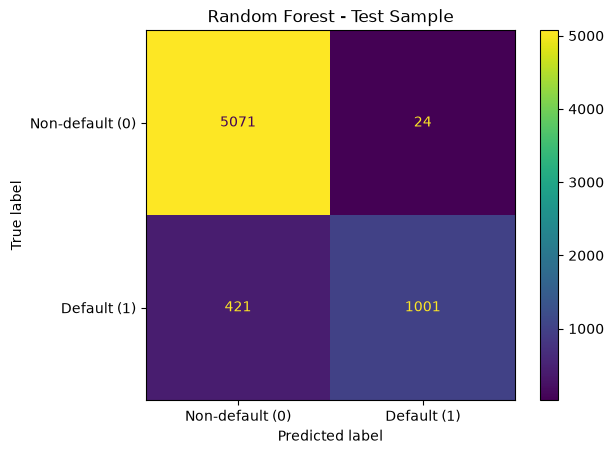

In [73]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Convert predicted PD into predicted class
threshold = 0.50
y_pred = (test_pred >= threshold).astype(int)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

print(cm)

# Visualize
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default (0)", "Default (1)"]
)

disp.plot()
plt.title("Random Forest - Test Sample")
plt.show()

## 12. Model diagnostics — ROC, CAP, KS, precision-recall

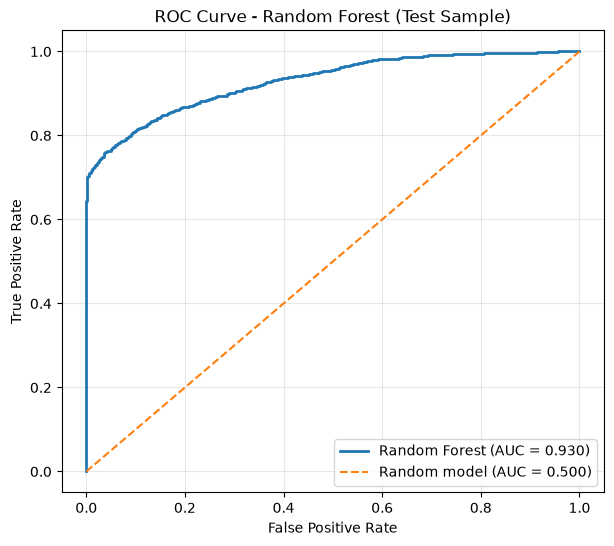

In [78]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, test_pred)

# AUC
auc = roc_auc_score(y_test, test_pred)

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    fpr,
    tpr,
    linewidth=2,
    label=f"Random Forest (AUC = {auc:.3f})"
)

# Random model benchmark
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random model (AUC = 0.500)"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Test Sample)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

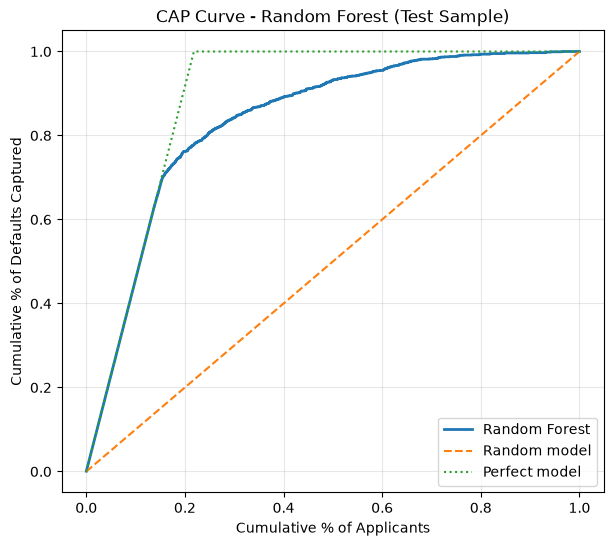

In [79]:
import numpy as np
import matplotlib.pyplot as plt

# Create dataframe with actual default and predicted PD
cap_df = pd.DataFrame({
    "actual": y_test.values,
    "pred_pd": test_pred
})

# Sort from highest predicted risk to lowest
cap_df = cap_df.sort_values(
    "pred_pd",
    ascending=False
).reset_index(drop=True)

# Cumulative population %
population = np.arange(1, len(cap_df) + 1) / len(cap_df)

# Cumulative % of actual defaults captured
defaults_captured = (
    cap_df["actual"].cumsum() /
    cap_df["actual"].sum()
)

# Perfect model
default_rate = cap_df["actual"].mean()

perfect_x = [0, default_rate, 1]
perfect_y = [0, 1, 1]

# Plot
plt.figure(figsize=(7, 6))

plt.plot(
    population,
    defaults_captured,
    linewidth=2,
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random model"
)

plt.plot(
    perfect_x,
    perfect_y,
    linestyle=":",
    label="Perfect model"
)

plt.xlabel("Cumulative % of Applicants")
plt.ylabel("Cumulative % of Defaults Captured")
plt.title("CAP Curve - Random Forest (Test Sample)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

KS: 0.723
PD at maximum KS: 0.295


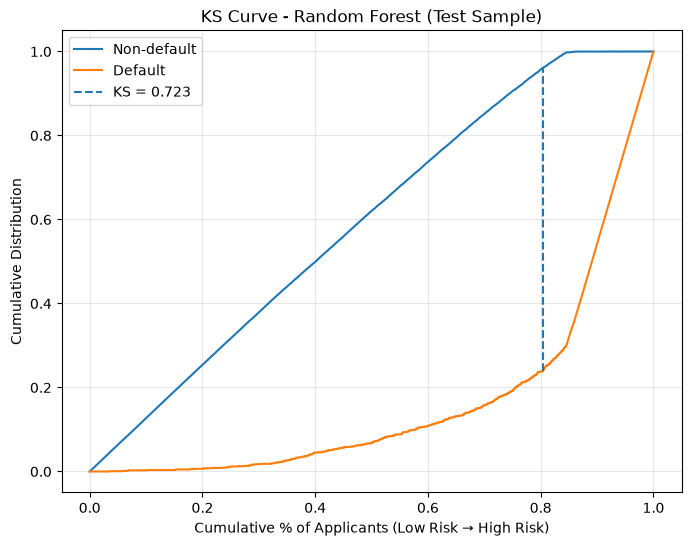

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Create test dataframe
ks_df = pd.DataFrame({
    "actual": y_test.values,
    "pred_pd": test_pred
})

# Sort from LOW risk to HIGH risk
ks_df = ks_df.sort_values(
    "pred_pd",
    ascending=True
).reset_index(drop=True)

# Cumulative distributions
ks_df["cum_good"] = (
    (ks_df["actual"] == 0).cumsum()
    / (ks_df["actual"] == 0).sum()
)

ks_df["cum_bad"] = (
    (ks_df["actual"] == 1).cumsum()
    / (ks_df["actual"] == 1).sum()
)

# Difference between distributions
ks_df["difference"] = abs(
    ks_df["cum_good"] - ks_df["cum_bad"]
)

# KS statistic
ks_index = ks_df["difference"].idxmax()
ks_value = ks_df.loc[ks_index, "difference"]
ks_pd = ks_df.loc[ks_index, "pred_pd"]

# Population position
population = (
    np.arange(1, len(ks_df) + 1)
    / len(ks_df)
)

print("KS:", round(ks_value, 3))
print("PD at maximum KS:", round(ks_pd, 3))

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    population,
    ks_df["cum_good"],
    label="Non-default"
)

plt.plot(
    population,
    ks_df["cum_bad"],
    label="Default"
)

# KS line
plt.vlines(
    population[ks_index],
    ks_df.loc[ks_index, "cum_bad"],
    ks_df.loc[ks_index, "cum_good"],
    linestyles="--",
    label=f"KS = {ks_value:.3f}"
)

plt.xlabel("Cumulative % of Applicants (Low Risk → High Risk)")
plt.ylabel("Cumulative Distribution")
plt.title("KS Curve - Random Forest (Test Sample)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

Average Precision: 0.881
Baseline: 0.218


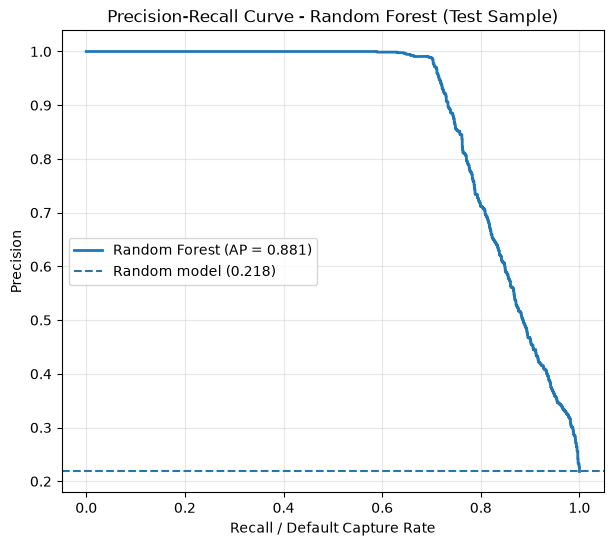

In [81]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score
)
import matplotlib.pyplot as plt

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(
    y_test,
    test_pred
)

# Average Precision
ap = average_precision_score(
    y_test,
    test_pred
)

# Baseline = default rate
baseline = y_test.mean()

print("Average Precision:", round(ap, 3))
print("Baseline:", round(baseline, 3))

plt.figure(figsize=(7, 6))

plt.plot(
    recall,
    precision,
    linewidth=2,
    label=f"Random Forest (AP = {ap:.3f})"
)

plt.axhline(
    y=baseline,
    linestyle="--",
    label=f"Random model ({baseline:.3f})"
)

plt.xlabel("Recall / Default Capture Rate")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest (Test Sample)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 13. Feature importance

In [82]:
import pandas as pd
import matplotlib.pyplot as plt

# Feature names after preprocessing
feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Random Forest importance
importance = (
    rf_model
    .named_steps["rf"]
    .feature_importances_
)

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values(
    "importance",
    ascending=False
)

importance_df.head(20)

,feature,importance
5,num__loan_percent_income,0.26
1,num__person_income,0.14
4,num__loan_int_rate,0.10
10,cat__person_home_ownership_RENT,0.07
20,cat__loan_grade_D,0.07
3,num__loan_amnt,0.05
2,num__person_emp_length,0.04
7,cat__person_home_ownership_MORTGAGE,0.03
11,cat__loan_intent_DEBTCONSOLIDATION,0.03
9,cat__person_home_ownership_OWN,0.02


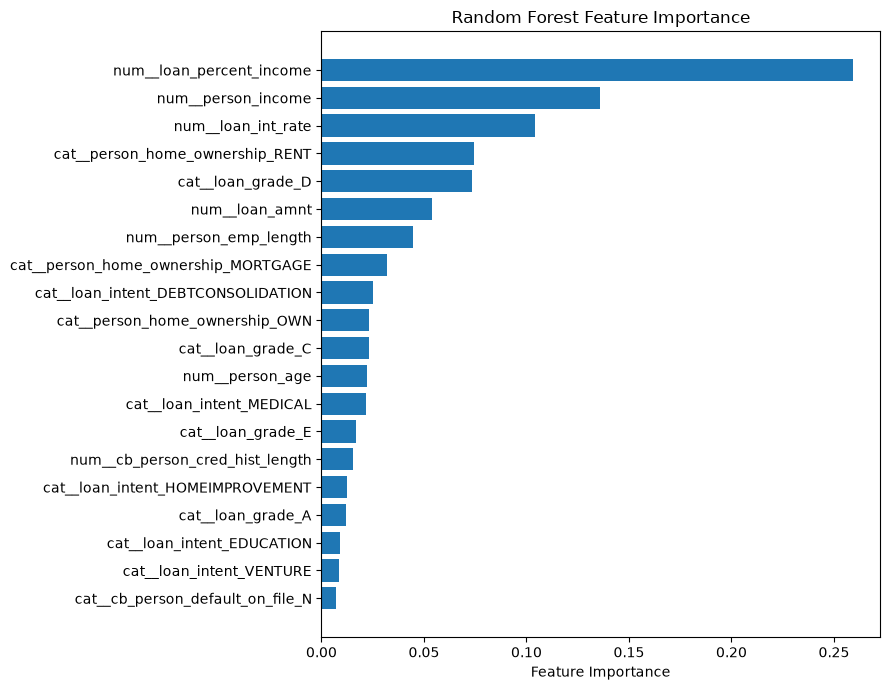

In [83]:
top20 = importance_df.head(20).sort_values(
    "importance",
    ascending=True
)

plt.figure(figsize=(9, 7))

plt.barh(
    top20["feature"],
    top20["importance"]
)

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()

plt.show()

## 14. Calibration

In [84]:
calibration_df = pd.DataFrame({
    "actual": y_test.values,
    "pred_pd": test_pred
})

# Divide borrowers into 10 groups based on predicted PD
calibration_df["pd_band"] = pd.qcut(
    calibration_df["pred_pd"],
    q=10,
    duplicates="drop"
)

calibration_table = (
    calibration_df
    .groupby("pd_band", observed=True)
    .agg(
        n=("actual", "count"),
        defaults=("actual", "sum"),
        avg_predicted_pd=("pred_pd", "mean"),
        observed_dr=("actual", "mean")
    )
)

calibration_table["difference"] = (
    calibration_table["avg_predicted_pd"]
    - calibration_table["observed_dr"]
)

calibration_table.round(4)

,n,defaults,avg_predicted_pd,observed_dr,difference
pd_band,,,,,
"(-0.000719, 0.0127]",652,4,0.01,0.01,0.00
"(0.0127, 0.0269]",652,5,0.02,0.01,0.01
"(0.0269, 0.0431]",651,16,0.03,0.02,0.01
"(0.0431, 0.061]",652,39,0.05,0.06,-0.01
"(0.061, 0.0844]",652,33,0.07,0.05,0.02
"(0.0844, 0.113]",651,57,0.10,0.09,0.01
"(0.113, 0.162]",652,70,0.13,0.11,0.03
"(0.162, 0.286]",651,114,0.21,0.18,0.04
"(0.286, 0.898]",652,432,0.60,0.66,-0.06


In [85]:
from sklearn.metrics import brier_score_loss

brier = brier_score_loss(
    y_test,
    test_pred
)

print("Brier Score:", round(brier, 4))

Brier Score: 0.0599


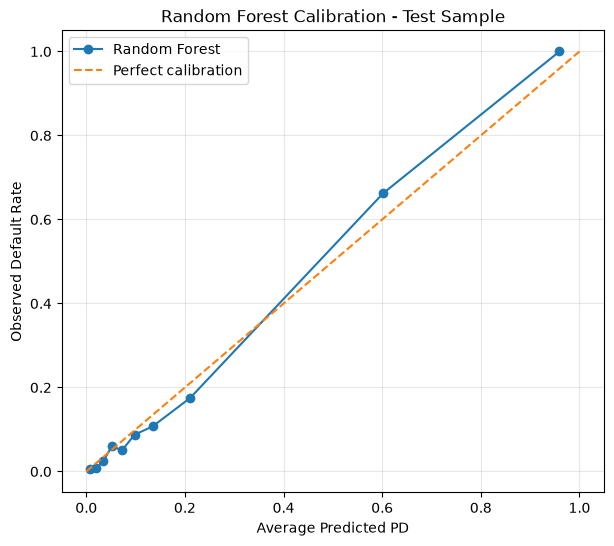

In [86]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))

plt.plot(
    calibration_table["avg_predicted_pd"],
    calibration_table["observed_dr"],
    marker="o",
    label="Random Forest"
)

# Perfect calibration line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect calibration"
)

plt.xlabel("Average Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("Random Forest Calibration - Test Sample")

plt.legend()
plt.grid(alpha=0.3)
plt.show()

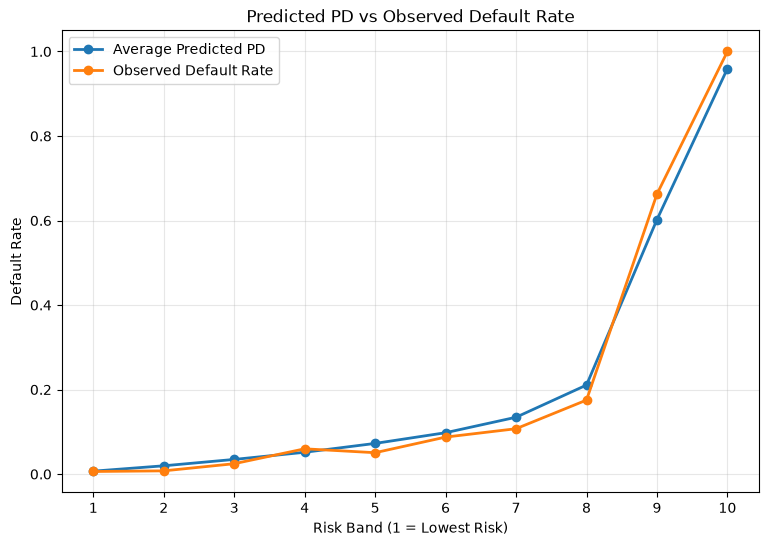

In [87]:
import matplotlib.pyplot as plt
import numpy as np

plot_df = calibration_table.reset_index()

x = np.arange(1, len(plot_df) + 1)

plt.figure(figsize=(9, 6))

plt.plot(
    x,
    plot_df["avg_predicted_pd"],
    marker="o",
    linewidth=2,
    label="Average Predicted PD"
)

plt.plot(
    x,
    plot_df["observed_dr"],
    marker="o",
    linewidth=2,
    label="Observed Default Rate"
)

plt.xlabel("Risk Band (1 = Lowest Risk)")
plt.ylabel("Default Rate")
plt.title("Predicted PD vs Observed Default Rate")
plt.xticks(x)
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## 15. SHAP explainability

In [90]:
# Prepare test data for SHAP

import pandas as pd

# Use 1,000 observations to keep SHAP reasonably fast
X_shap_original = X_test.sample(
    n=min(1000, len(X_test)),
    random_state=42
)

# Transform using the fitted RF preprocessing
X_shap_transformed = (
    rf_model
    .named_steps["preprocessor"]
    .transform(X_shap_original)
)

# Get feature names after one-hot encoding
feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Create SHAP dataframe
X_test_shap = pd.DataFrame(
    X_shap_transformed,
    columns=feature_names
)

print("X_test_shap created:", "X_test_shap" in globals())
print("Shape:", X_test_shap.shape)

X_test_shap created: True
Shape: (1000, 26)


In [91]:
import shap

rf = rf_model.named_steps["rf"]

explainer = shap.TreeExplainer(rf)

shap_values = explainer.shap_values(
    X_test_shap
)

print("SHAP generated:", "shap_values" in globals())

if isinstance(shap_values, list):
    print("SHAP shapes:", [x.shape for x in shap_values])
else:
    print("SHAP shape:", shap_values.shape)

SHAP generated: True
SHAP shape: (1000, 26, 2)


                                Feature  Mean_ABS_SHAP
5              num__loan_percent_income           0.08
1                    num__person_income           0.05
10      cat__person_home_ownership_RENT           0.04
20                    cat__loan_grade_D           0.04
4                    num__loan_int_rate           0.04
17                    cat__loan_grade_A           0.03
19                    cat__loan_grade_C           0.02
2                num__person_emp_length           0.02
11   cat__loan_intent_DEBTCONSOLIDATION           0.01
7   cat__person_home_ownership_MORTGAGE           0.01
9        cat__person_home_ownership_OWN           0.01
16             cat__loan_intent_VENTURE           0.01
18                    cat__loan_grade_B           0.01
14             cat__loan_intent_MEDICAL           0.01
3                        num__loan_amnt           0.01


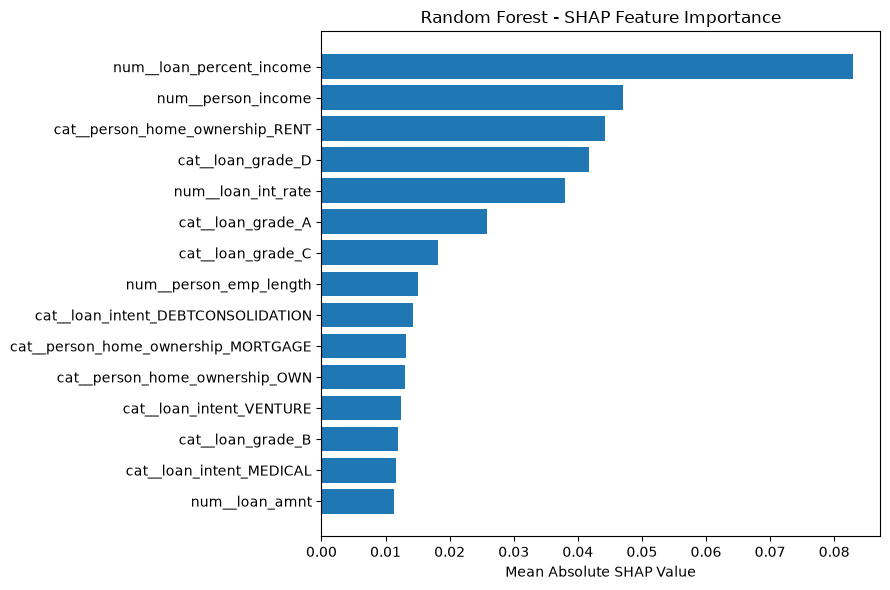

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

shap_importance = pd.DataFrame({
    "Feature": X_test_shap.columns,
    "Mean_ABS_SHAP": np.abs(shap_default).mean(axis=0)
}).sort_values(
    "Mean_ABS_SHAP",
    ascending=False
)

print(shap_importance.head(15))

top15 = shap_importance.head(15).sort_values(
    "Mean_ABS_SHAP"
)

plt.figure(figsize=(9, 6))

plt.barh(
    top15["Feature"],
    top15["Mean_ABS_SHAP"]
)

plt.xlabel("Mean Absolute SHAP Value")
plt.title("Random Forest - SHAP Feature Importance")
plt.tight_layout()
plt.show()

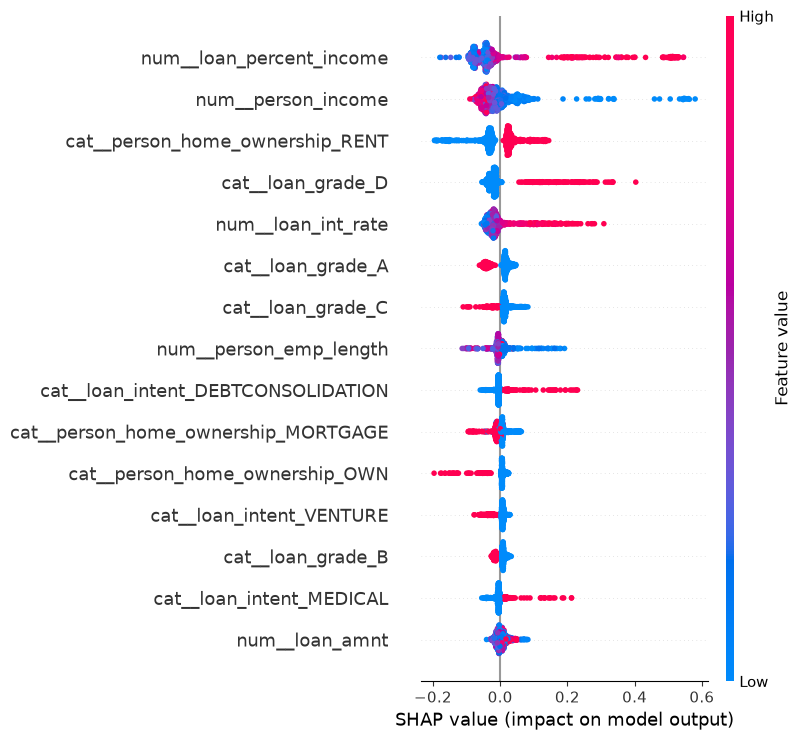

In [94]:
shap.summary_plot(
    shap_default,
    X_test_shap,
    feature_names=X_test_shap.columns,
    max_display=15
)

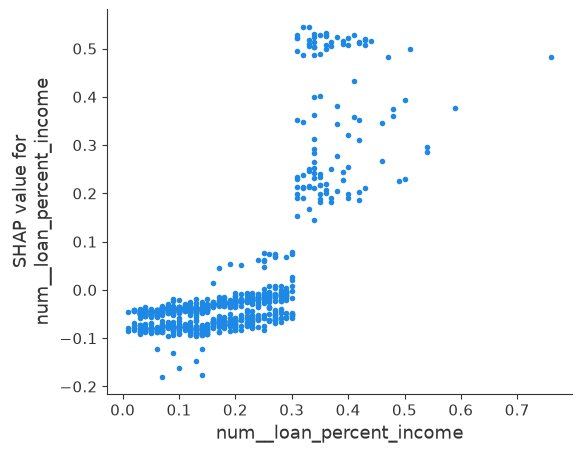

In [95]:
shap.dependence_plot(
    "num__loan_percent_income",
    shap_default,
    X_test_shap,
    interaction_index=None
)


## 16. Credit policy / score cutoff analysis

In [97]:
# Generate predicted PD for the test sample

rf_test_pd = rf_model.predict_proba(X_test)[:, 1]

print("Predictions created:", len(rf_test_pd))
print("Average predicted PD:", round(rf_test_pd.mean(), 4))
print("Observed default rate:", round(y_test.mean(), 4))

Predictions created: 6517
Average predicted PD: 0.2191
Observed default rate: 0.2182


In [98]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(y_test, rf_test_pd)
ar = 2 * auc - 1

print("Test AUC:", round(auc, 3))
print("Test AR :", round(ar, 3))

Test AUC: 0.93
Test AR : 0.86


In [101]:
# ============================================================
# CREDIT POLICY ANALYSIS USING CREDIT SCORE
# Higher score = lower predicted risk
# ============================================================

policy_df = pd.DataFrame({
    "actual_default": y_test.values,
    "predicted_pd": rf_test_pd
})

# Convert predicted PD into a simple 0-100 credit score
policy_df["credit_score"] = (
    100 * (1 - policy_df["predicted_pd"])
)

# Candidate score cutoffs
score_cutoffs = np.arange(50, 96, 5)

results = []

total_defaults = policy_df["actual_default"].sum()

for cutoff in score_cutoffs:

    # Approve if score >= cutoff
    approved = policy_df[
        policy_df["credit_score"] >= cutoff
    ]

    rejected = policy_df[
        policy_df["credit_score"] < cutoff
    ]

    approval_rate = len(approved) / len(policy_df)

    approved_dr = (
        approved["actual_default"].mean()
        if len(approved) > 0
        else np.nan
    )

    rejected_dr = (
        rejected["actual_default"].mean()
        if len(rejected) > 0
        else np.nan
    )

    bad_capture_rate = (
        rejected["actual_default"].sum()
        / total_defaults
    )

    results.append({
        "Cutoff Score": cutoff,
        "Approval Rate": approval_rate,
        "Approved DR": approved_dr,
        "Rejected DR": rejected_dr,
        "Bad Capture Rate": bad_capture_rate,
        "Approved N": len(approved),
        "Rejected N": len(rejected)
    })


score_cutoff_table = pd.DataFrame(results)


# Convert rates to percentages for presentation
display_score_table = score_cutoff_table.copy()

for col in [
    "Approval Rate",
    "Approved DR",
    "Rejected DR",
    "Bad Capture Rate"
]:
    display_score_table[col] = (
        display_score_table[col] * 100
    ).round(1)

display_score_table

,Cutoff Score,Approval Rate,Approved DR,Rejected DR,Bad Capture Rate,Approved N,Rejected N
0,50,84.30,7.70,97.70,70.40,5492,1025
1,55,83.90,7.50,96.30,71.10,5467,1050
2,60,83.30,7.40,93.90,71.90,5428,1089
3,65,82.20,7.10,90.00,73.30,5358,1159
4,70,80.50,6.60,84.70,75.70,5245,1272
5,75,78.20,6.20,77.80,77.80,5095,1422
6,80,74.70,5.60,69.80,80.90,4869,1648
7,85,68.40,4.70,58.80,85.30,4455,2062
8,90,55.90,3.70,44.80,90.60,3641,2876
9,95,34.20,1.50,32.40,97.70,2228,4289


## 17. Logistic regression — held-out test performance

A separate sklearn pipeline, fit on the training set and scored on the untouched test set — the fair, apples-to-apples comparison against the random forest.

In [106]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression

# Same variables used in our modelling
numeric_vars = [
    "person_age",
    "person_income",
    "person_emp_length",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length"
]

categorical_vars = [
    "person_home_ownership",
    "loan_intent",
    "loan_grade",
    "cb_person_default_on_file"
]

# Numeric preprocessing
numeric_transformer_logit = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
categorical_transformer_logit = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
logit_preprocessor = ColumnTransformer([
    ("num", numeric_transformer_logit, numeric_vars),
    ("cat", categorical_transformer_logit, categorical_vars)
])

# Logistic Regression pipeline
logit_model = Pipeline([
    ("preprocessor", logit_preprocessor),
    ("logit", LogisticRegression(max_iter=1000))
])

# Fit ONLY on existing training sample
logit_model.fit(X_train, y_train)

# Predict on existing test sample
logit_pd = logit_model.predict_proba(X_test)[:, 1]

print("Logistic model fitted.")
print("Test predictions:", len(logit_pd))

Logistic model fitted.
Test predictions: 6517


In [107]:
from sklearn.metrics import roc_auc_score

logit_auc = roc_auc_score(y_test, logit_pd)
logit_ar = 2 * logit_auc - 1

print("Logistic Test AUC:", round(logit_auc, 3))
print("Logistic Test AR :", round(logit_ar, 3))

Logistic Test AUC: 0.869
Logistic Test AR : 0.739


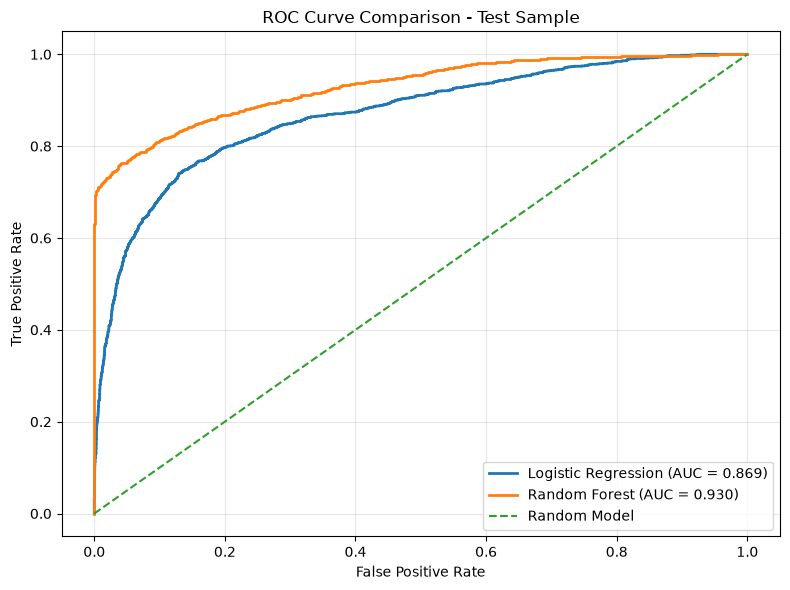

In [108]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Logistic Regression
fpr_logit, tpr_logit, _ = roc_curve(y_test, logit_pd)
logit_auc = roc_auc_score(y_test, logit_pd)

# Random Forest
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_test_pd)
rf_auc = roc_auc_score(y_test, rf_test_pd)

# Plot
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logit,
    tpr_logit,
    linewidth=2,
    label=f"Logistic Regression (AUC = {logit_auc:.3f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Model"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison - Test Sample")

plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 18. Full model comparison

In [109]:
from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    brier_score_loss
)
import pandas as pd
import numpy as np


def model_metrics(y_true, pred_pd, threshold=0.50):

    pred_class = (pred_pd >= threshold).astype(int)

    tn, fp, fn, tp = confusion_matrix(
        y_true, pred_class
    ).ravel()

    auc = roc_auc_score(y_true, pred_pd)
    ar = 2 * auc - 1

    fpr, tpr, _ = roc_curve(y_true, pred_pd)
    ks = np.max(tpr - fpr)

    return {
        "AUC": auc,
        "AR": ar,
        "KS": ks,
        "Accuracy": accuracy_score(y_true, pred_class),
        "Precision": precision_score(y_true, pred_class),
        "Recall": recall_score(y_true, pred_class),
        "Specificity": tn / (tn + fp),
        "F1": f1_score(y_true, pred_class),
        "Brier Score": brier_score_loss(y_true, pred_pd)
    }


logit_metrics = model_metrics(
    y_test,
    logit_pd
)

rf_metrics = model_metrics(
    y_test,
    rf_test_pd
)


model_comparison = pd.DataFrame({
    "Logistic Regression": logit_metrics,
    "Random Forest": rf_metrics
})

model_comparison.round(3)

,Logistic Regression,Random Forest
AUC,0.87,0.93
AR,0.74,0.86
KS,0.61,0.72
Accuracy,0.87,0.93
Precision,0.77,0.98
Recall,0.56,0.70
Specificity,0.95,0.99
F1,0.65,0.82
Brier Score,0.10,0.06


## 19. Risk-band analysis and the highest-risk decile

In [110]:
# ============================================================
# RISK BAND / CALIBRATION ANALYSIS
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

risk_df = pd.DataFrame({
    "actual_default": y_test.values,
    "predicted_pd": rf_test_pd
})

# 10 equally sized groups based on predicted PD
# 1 = lowest risk, 10 = highest risk
risk_df["risk_band"] = (
    pd.qcut(
        risk_df["predicted_pd"],
        q=10,
        labels=False,
        duplicates="drop"
    ) + 1
)

risk_table = (
    risk_df
    .groupby("risk_band")
    .agg(
        N=("actual_default", "count"),
        Defaults=("actual_default", "sum"),
        Average_Predicted_PD=("predicted_pd", "mean"),
        Observed_Default_Rate=("actual_default", "mean")
    )
)

# Percentage version for display
risk_table_display = risk_table.copy()

risk_table_display["Average Predicted PD (%)"] = (
    risk_table_display["Average_Predicted_PD"] * 100
).round(1)

risk_table_display["Observed Default Rate (%)"] = (
    risk_table_display["Observed_Default_Rate"] * 100
).round(1)

risk_table_display[
    [
        "N",
        "Defaults",
        "Average Predicted PD (%)",
        "Observed Default Rate (%)"
    ]
]

,N,Defaults,Average Predicted PD (%),Observed Default Rate (%)
risk_band,,,,
1,652,4,0.70,0.60
2,652,5,2.00,0.80
3,651,16,3.50,2.50
4,652,39,5.20,6.00
5,652,33,7.30,5.10
6,651,57,9.80,8.80
7,652,70,13.50,10.70
8,651,114,21.10,17.50
9,652,432,60.20,66.30


In [112]:
# Highest-risk band positions
highest_risk_mask = risk_df["risk_band"] == 10

# Pull the same rows from X_test by position
highest_risk_X = X_test.reset_index(drop=True).loc[
    highest_risk_mask
].copy()

highest_risk_X["actual_default"] = risk_df.loc[
    highest_risk_mask,
    "actual_default"
].values

highest_risk_X["predicted_pd"] = risk_df.loc[
    highest_risk_mask,
    "predicted_pd"
].values

print("N:", len(highest_risk_X))
print(
    "Observed DR:",
    round(highest_risk_X["actual_default"].mean(), 4)
)

print("\nLoan Grade:")
print(
    highest_risk_X["loan_grade"]
    .value_counts(normalize=True)
    .sort_index()
)

print("\nPrevious Default:")
print(
    highest_risk_X["cb_person_default_on_file"]
    .value_counts(normalize=True)
)

print("\nHome Ownership:")
print(
    highest_risk_X["person_home_ownership"]
    .value_counts(normalize=True)
)

print("\nNumerical Summary:")
print(
    highest_risk_X[
        [
            "person_income",
            "loan_amnt",
            "loan_int_rate",
            "loan_percent_income",
            "predicted_pd"
        ]
    ]
    .describe()
    .round(3)
)

N: 652
Observed DR: 1.0

Loan Grade:
loan_grade
A   0.14
B   0.27
C   0.15
D   0.38
E   0.05
F   0.01
G   0.00
Name: proportion, dtype: float64

Previous Default:
cb_person_default_on_file
N   0.70
Y   0.30
Name: proportion, dtype: float64

Home Ownership:
person_home_ownership
RENT       0.93
MORTGAGE   0.06
OWN        0.00
Name: proportion, dtype: float64

Numerical Summary:
       person_income  loan_amnt  loan_int_rate  loan_percent_income  \
count         652.00     652.00         609.00               652.00   
mean       40,413.28  12,347.97          13.01                 0.32   
std        20,590.14   6,687.19           3.13                 0.12   
min         8,400.00   1,000.00           5.42                 0.01   
25%        26,359.25   7,500.00          10.74                 0.25   
50%        36,000.00  11,050.00          13.49                 0.33   
75%        51,500.00  16,000.00          15.58                 0.39   
max       173,000.00  35,000.00          21.74      

## Limitations

This project is designed as a modelling demonstration using a public credit-risk dataset. Results should therefore be interpreted as analytical rather than production estimates.

Model validation is based on a stratified holdout sample and cross-validation rather than out-of-time validation. In a production setting, temporal stability and population drift would need to be assessed.

Loan grade and interest rate may contain information from an existing underwriting process and therefore potentially contribute embedded credit-risk information to the model. Their availability and appropriateness at the intended decision point should be assessed before production use.

Random Forest provides strong discriminatory performance, but discrimination and PD calibration are separate considerations. Predicted PD should be independently calibrated and monitored before being used for expected-loss estimation or pricing.

Finally, the cutoff analysis illustrates the trade-off between approval volume and portfolio risk using observed outcomes in the test sample. A production cutoff would additionally incorporate risk appetite, expected loss, pricing, capital requirements, portfolio constraints and business objectives.



## Key Findings

Loan-to-Income Ratio emerged as the strongest individual risk indicator and remained the most important feature in the Random Forest SHAP analysis. Risk increased particularly strongly at higher LTI levels.

Logistic Regression provided a strong interpretable benchmark with AUC 0.869 / AR 0.739, while Random Forest improved test discrimination to approximately AUC 0.930 / AR 0.860. The improvement suggests meaningful nonlinearities and interactions beyond the logistic specification.

Risk-band analysis showed strong separation between low- and high-risk borrowers, while comparison of predicted PD with observed default rates also highlighted the importance of assessing calibration separately from ranking performance.

Finally, converting model PD into a simple credit score demonstrated how model output can support credit policy. For example, increasing the minimum score from 70 to 90 reduced the test-sample approval rate from 80.5% to 55.9%, while the observed default rate among approved borrowers declined from 6.6% to 3.7%. The appropriate cutoff is therefore a risk-policy and business decision rather than a model-performance decision alone.